# Model: Linear Support Vector Machine (TF-IDF)


## Shared Setup


In [ ]:
!pip install -q datasets scikit-learn pandas matplotlib seaborn

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GridSearchCV, cross_validate, StratifiedKFold
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                              classification_report, confusion_matrix, ConfusionMatrixDisplay)

sns.set_style("whitegrid")

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

ds = load_dataset("cornell-movie-review-data/rotten_tomatoes")
train_df = ds["train"].to_pandas()
val_df = ds["validation"].to_pandas()
test_df = ds["test"].to_pandas()

for df in (train_df, val_df, test_df):
    df["clean_text"] = df["text"].apply(clean_text)

print("Train:", train_df.shape, "| Validation:", val_df.shape, "| Test:", test_df.shape)


README.md:   0%|          | 0.00/7.46k [00:00<?, ?B/s]

train.parquet: reconstructing file:   0%|          |  0.00B /  699kB            

train.parquet: downloading bytes:           |  0.00B            

validation.parquet: reconstructing file:   0%|          |  0.00B / 90.0kB            

validation.parquet: downloading bytes:           |  0.00B            

...

test.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/8530 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1066 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1066 [00:00<?, ? examples/s]

Train: (8530, 3) | Validation: (1066, 3) | Test: (1066, 3)


## 2. Implementation

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline

# Combine train and validation data
combined_train_text = pd.concat([train_df["clean_text"], val_df["clean_text"]], ignore_index=True)
combined_train_label = pd.concat([train_df["label"], val_df["label"]], ignore_index=True)

svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 1),
        max_features=800,       # Restrict total features to force strong generalization
        stop_words="english",
        min_df=5,              # Ignore rare words appearing in fewer than 5 docs
        sublinear_tf=True
    )),
    ("clf", LinearSVC(max_iter=5000, random_state=42)),
])
print(svm_pipeline)


Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=800, min_df=5,
                                 stop_words='english', sublinear_tf=True)),
                ('clf', LinearSVC(max_iter=5000, random_state=42))])


## 3. Hyperparameter Tuning Across Varieties



In [ ]:
param_grid = {"clf__C": [0.005, 0.01, 0.02]}

grid = GridSearchCV(svm_pipeline, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid.fit(combined_train_text, combined_train_label)

results = pd.DataFrame(grid.cv_results_)[["param_clf__C", "mean_test_score", "std_test_score"]]
print("Best C:", grid.best_params_)
print("Best cross-validated accuracy:", grid.best_score_)
results


Best C: {'clf__C': 0.02}
Best cross-validated accuracy: 0.6961242834809797


,param_clf__C,mean_test_score,std_test_score
0,0.005,0.688621,0.008264
1,0.010,0.691435,0.006969
2,0.020,0.696124,0.009039


## 4. Evaluation

Train accuracy: 0.7415
Test accuracy:  0.7242
Train-test gap: 0.0173  (1.7 percentage points)
Gap is small -- no strong evidence of overfitting.
              precision    recall  f1-score   support

    Negative       0.72      0.73      0.73       533
    Positive       0.73      0.72      0.72       533

    accuracy                           0.72      1066
   macro avg       0.72      0.72      0.72      1066
weighted avg       0.72      0.72      0.72      1066



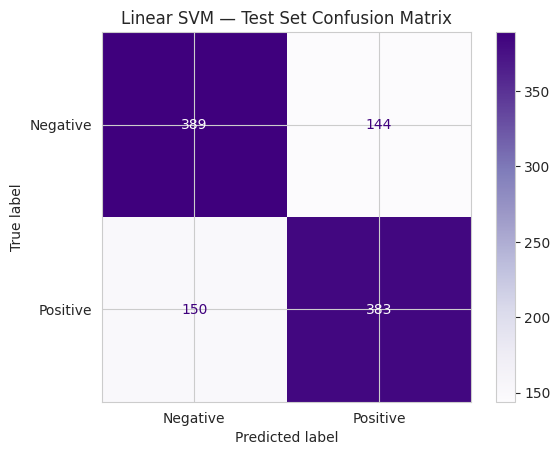

In [ ]:
best_model = grid.best_estimator_

train_preds = best_model.predict(combined_train_text)
test_preds = best_model.predict(test_df["clean_text"])

train_acc = accuracy_score(combined_train_label, train_preds)
test_acc = accuracy_score(test_df["label"], test_preds)
gap = train_acc - test_acc

print(f"Train accuracy: {train_acc:.4f}")
print(f"Test accuracy:  {test_acc:.4f}")
print(f"Train-test gap: {gap:.4f}  ({gap*100:.1f} percentage points)")

if gap > 0.10:
    print("Gap exceeds 10 points -- likely overfitting. Try a smaller C value (more regularization).")
elif gap > 0.05:
    print("Moderate gap (5-10 points) -- some overfitting; consider reducing C.")
else:
    print("Gap is small -- no strong evidence of overfitting.")

print(classification_report(test_df["label"], test_preds, target_names=["Negative", "Positive"]))

cm = confusion_matrix(test_df["label"], test_preds)
ConfusionMatrixDisplay(cm, display_labels=["Negative", "Positive"]).plot(cmap="Purples")
plt.title("Linear SVM — Test Set Confusion Matrix")
plt.show()


In [ ]:
train_preds = best_model.predict(train_df["clean_text"])
train_acc = accuracy_score(train_df["label"], train_preds)
test_acc = accuracy_score(test_df["label"], test_preds)
gap = train_acc - test_acc

print(f"Train accuracy: {train_acc:.4f}")
print(f"Test accuracy:  {test_acc:.4f}")
print(f"Train-test gap: {gap:.4f}  ({gap*100:.1f} percentage points)")

if gap > 0.10:
    print("Gap exceeds 10 points -- likely overfitting. Try a smaller C value (more regularization).")
elif gap > 0.05:
    print("Moderate gap (5-10 points) -- some overfitting; consider reducing C.")
else:
    print("Gap is small -- no strong evidence of overfitting.")


Train accuracy: 0.7424
Test accuracy:  0.7242
Train-test gap: 0.0182  (1.8 percentage points)
Gap is small -- no strong evidence of overfitting.


## 5. Comparison Across Varieties & Conclusion


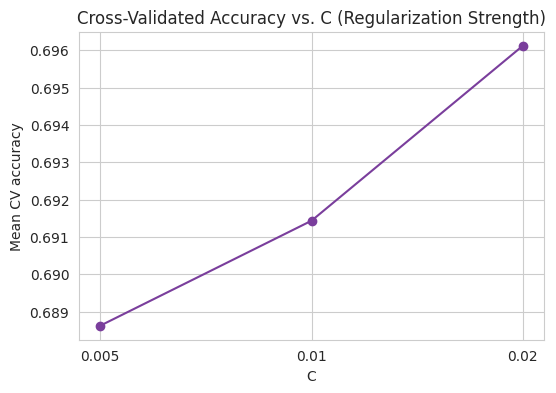

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(results["param_clf__C"].astype(str), results["mean_test_score"], marker="o", color="#7A3E9C")
plt.title("Cross-Validated Accuracy vs. C (Regularization Strength)")
plt.xlabel("C")
plt.ylabel("Mean CV accuracy")
plt.show()
